Bu projede bir telekomünikasyon şirketine ait müşteri verileri kullanılarak müşteri terk (Customer Churn) tahmini gerçekleştirilmiştir. Çalışmanın temel amacı, hizmeti bırakma riski taşıyan müşterileri önceden belirleyerek şirketlerin müşteri kaybını azaltmasına yardımcı olmaktır. Proje kapsamında veri seti üzerinde veri ön işleme, eksik veri kontrolü, kategorik değişken dönüşümleri ve feature engineering işlemleri uygulanmıştır. Ardından Logistic Regression, Random Forest, XGBoost ve Deep Learning (ANN) modelleri kullanılarak farklı classification yaklaşımları geliştirilmiş ve performans karşılaştırmaları yapılmıştır. Böylece hem klasik makine öğrenmesi algoritmaları hem de deep learning yöntemleri kullanılarak müşteri davranışlarının analiz edilmesi amaçlanmıştır.

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

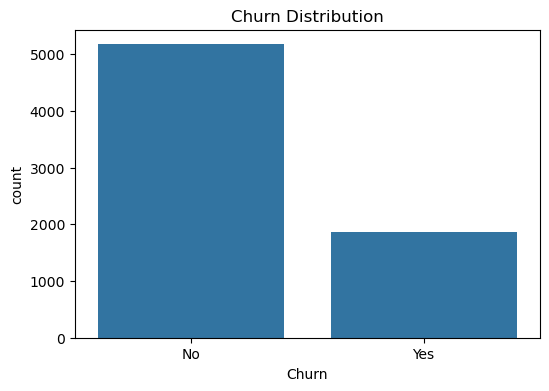

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="Churn",data=df)

plt.title("Churn Distribution")

plt.show()

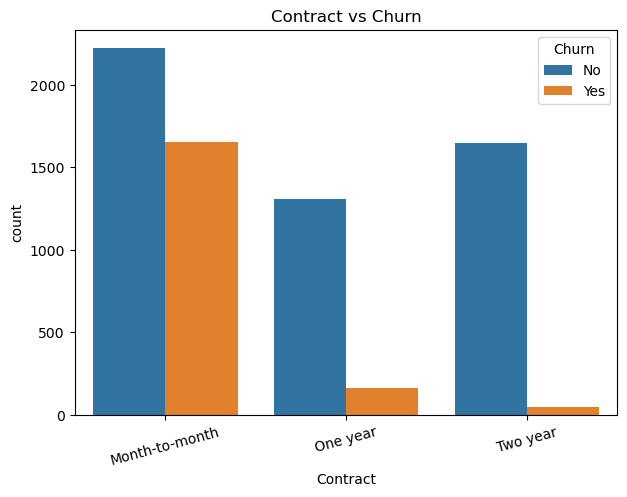

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract vs Churn")

plt.xticks(rotation=15)

plt.show()

In [9]:
# Churn değişkenini sayısal hale çeviriyoruz.
df["Churn"] = df["Churn"].replace({"No": 0, "Yes": 1})

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_20620\2105245127.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"No": 0, "Yes": 1})


In [10]:
df["Churn"].unique()

array([0, 1])

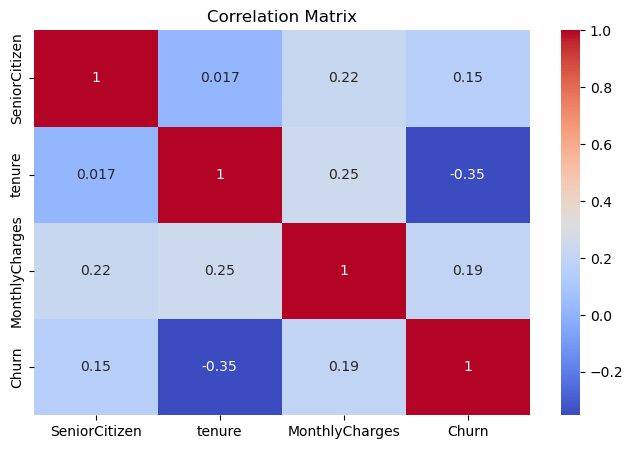

In [11]:
# Sayısal değişkenler arasındaki korelasyonu inceliyoruz.
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(
        include=["int64","float64"]
    ).corr(),
    
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [12]:
#Tahmin için anlam ifade etmeyen müşteri ID sütununu siliyoruz.
df = df.drop("customerID", axis=1)

In [13]:
#Evet-Hayır tarzındaki sütunları sayısal hale çeviriyoruz.
binary_columns = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_columns:
    
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0,
        "Male": 1,
        "Female": 0
    })

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [15]:
df["MultipleLines"].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [16]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [17]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [18]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [19]:
# İnternet veya telefon hizmeti olmayan değerleri sadeleştiriyoruz.
replace_columns = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies","MultipleLines"]

for col in replace_columns:
    
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

In [20]:
# Şimdi kalan Yes/No sütunlarını 0-1’e çeviriyoruz.
yes_no_columns = [ "MultipleLines", "OnlineSecurity", "OnlineBackup","DeviceProtection","TechSupport", "StreamingTV","StreamingMovies"]

for col in yes_no_columns:
    
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [22]:
df = pd.get_dummies(df, columns=["InternetService","Contract","PaymentMethod"],drop_first=True)

In [23]:
df.shape

(7043, 24)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [30]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [35]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [36]:
x = df.drop("Churn", axis=1)

y = df["Churn"]

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [39]:
tahmin=log_model.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, tahmin))
    
print(confusion_matrix(y_test, tahmin))

print(classification_report(y_test, tahmin))

Accuracy: 0.8069552874378992
[[928 107]
 [165 209]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [49]:
rf_tahmin=rf_model.predict(x_test)

In [50]:
print("Accuracy:",
      accuracy_score(y_test, rf_tahmin))

print(confusion_matrix(y_test, rf_tahmin))

print(classification_report(y_test, rf_tahmin))

Accuracy: 0.8076650106458482
[[942  93]
 [178 196]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [44]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,True,False,False,False,False,True,False


In [45]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(x_train, y_train)    

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
xgb_pred = xgb_model.predict(x_test)

In [47]:
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy: 0.78708303761533
[[913 122]
 [178 196]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [51]:
import joblib

joblib.dump(log_model,"churn_model.pkl")

['churn_model.pkl']

Proje sonucunda en başarılı performans Logistic Regression modeli ile elde edilmiştir. Model yaklaşık %81 doğruluk oranına ulaşmış ve müşteri terk etme durumlarını başarılı şekilde tahmin etmiştir. Özellikle churn eden müşterilerin belirlenmesinde dengeli sonuçlar elde edilmiştir. Ayrıca Random Forest ve XGBoost algoritmaları ile karşılaştırmalar yapılarak modellerin güçlü ve zayıf yönleri analiz edilmiştir. Bu çalışma sayesinde müşteri davranışlarının analiz edilmesi ve müşteri kaybını önlemeye yönelik veri odaklı kararlar alınabilmesi amaçlanmıştır.

### Deep Learning

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dl_model = Sequential()

dl_model.add(Dense(128, activation="relu", input_shape=(x_train_scaled.shape[1],)))
dl_model.add(Dropout(0.2))

dl_model.add(Dense(64, activation="relu"))
dl_model.add(Dropout(0.2))

dl_model.add(Dense(32, activation="relu"))

dl_model.add(Dense(1, activation="sigmoid"))

dl_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = dl_model.fit(x_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7817 - loss: 0.4564 - val_accuracy: 0.7826 - val_loss: 0.4490
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8001 - loss: 0.4207 - val_accuracy: 0.7835 - val_loss: 0.4448
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8043 - loss: 0.4169 - val_accuracy: 0.7995 - val_loss: 0.4373
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8052 - loss: 0.4151 - val_accuracy: 0.7959 - val_loss: 0.4409
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8094 - loss: 0.4053 - val_accuracy: 0.7933 - val_loss: 0.4381
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8163 - loss: 0.4029 - val_accuracy: 0.7835 - val_loss: 0.4400
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8158 - loss: 0.4003 - val_accuracy: 0.7906 - val_loss: 0.4383
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8158 - loss: 0.3938 - val_accu

In [55]:
dl_prob = dl_model.predict(x_test_scaled)

dl_pred = (dl_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [56]:
print("Accuracy:", accuracy_score(y_test, dl_pred))

print(confusion_matrix(y_test, dl_pred))

print(classification_report(y_test, dl_pred))

Accuracy: 0.765791341376863
[[878 157]
 [173 201]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1035
           1       0.56      0.54      0.55       374

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.76      0.77      0.76      1409



In [57]:
dl_model.save("churn_dl_model.h5")

In [59]:
import joblib

joblib.dump(x.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

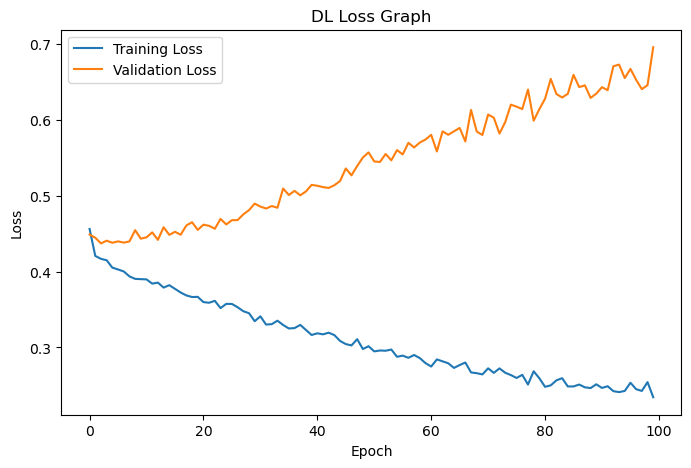

In [58]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("DL Loss Graph")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

Bu projede ayrıca müşteri terk tahmini için Deep Learning yaklaşımı da uygulanmıştır. ANN (Artificial Neural Network) modeli kullanılarak müşterilerin churn etme olasılığı tahmin edilmeye çalışılmıştır. Model eğitim sürecinde veri ölçeklendirme işlemleri uygulanmış ve çok katmanlı yapay sinir ağı mimarisi oluşturulmuştur. Deep Learning modeli yaklaşık %77 doğruluk oranı elde ederek başarılı sonuçlar üretmiştir. Ancak yapılan model karşılaştırmaları sonucunda tabular veri yapısında Logistic Regression modelinin daha yüksek performans gösterdiği görülmüştür. Buna rağmen Deep Learning yaklaşımının projeye eklenmesi sayesinde klasik makine öğrenmesi yöntemleri ile yapay sinir ağlarının performans farkları analiz edilmiş ve classification problemlerinde farklı model yaklaşımları karşılaştırılmıştır.